In [1]:
import pandas as pd
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import ParameterGrid

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    precision_recall_curve,
    auc,
    ConfusionMatrixDisplay
)


In [2]:
# ============================================================
# 1. PARÂMETROS DO MLP
# ============================================================

PARAM_GRID = {
    # Arquitetura da rede
    "hidden_layer_sizes": [
        (32, 16),
        (64, 32),
        (64, 32, 16),
        (128, 64, 32)
    ],

    # Taxa de aprendizado
    "learning_rate_init": [
        0.0001,
        0.0003,
        0.001,
        0.003
    ],

    # Tamanho do lote
    "batch_size": [
        32,
        64,
        128
    ],

    # Regularização L2
    "alpha": [
        0.0001,
        0.001,
        0.01
    ],

    # Quantidade máxima de épocas
    "max_iter": [
        50,
        100
    ]
}

# ============================================================
# PARÂMETROS FIXOS
# ============================================================

FIXED_PARAMS = {
    "activation": "relu",
    "solver": "adam",
    "early_stopping": True,
    "validation_fraction": 0.1,
    "n_iter_no_change": 10,
    "random_state": 42
}

THRESHOLD = 0.30

# ============================================================
# TODAS AS COMBINAÇÕES
# ============================================================

combinacoes = list(
    ParameterGrid(PARAM_GRID)
)

print(
    f"Quantidade de configurações: {len(combinacoes)}"
)

Quantidade de configurações: 288


In [3]:
# ============================================================
# 2. CARREGAMENTO DO DATASET
# ============================================================

arquivo = "../../tabela_final/table_orders_holidays_ecommerce_events.csv"


df = pd.read_csv(arquivo)

In [4]:


target_col = "delivered_on_time"
if target_col not in df.columns:
    raise ValueError(f"A coluna alvo '{target_col}' nao foi encontrada no CSV.")

# =====================================================================
# 1. ENGENHARIA DO SLA (Prazo da Transportadora - LAST MILE)
# =====================================================================
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'], utc=True)
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'], utc=True)
df['order_delivered_carrier_date'] = pd.to_datetime(df['order_delivered_carrier_date'], utc=True)

# Quantos dias a transportadora tem para entregar apos pegar o pacote?
df['prazo_transportadora_dias'] = (df['order_estimated_delivery_date'] - df['order_delivered_carrier_date']).dt.days

# Remover os casos onde a transportadora nunca pegou o pacote para evitar NaN no treino
df = df.dropna(subset=['prazo_transportadora_dias']).copy()

# Extraindo o mes da compra (sazonalidade - Black Friday, Natal)
df['purchase_month'] = df['order_purchase_timestamp'].dt.month

# =====================================================================
# 1b. FEATURES DE INTERAÇÃO (Adicionadas para aumentar o sinal)
# =====================================================================
df['prazo_por_km'] = df['prazo_transportadora_dias'] / (df['distance_km'] + 1)
df['frete_por_kg'] = df['freight_value'] / (df['product_weight_g'] / 1000 + 0.1)
df['densidade_produto'] = df['product_weight_g'] / (df['volume_cm3'] + 1)

# =====================================================================
# 2. ORDENAÇÃO CRONOLÓGICA (Baseada no momento da coleta)
# =====================================================================
df = df.sort_values('order_delivered_carrier_date').reset_index(drop=True)

# Divide em treino/teste com split temporal (Passado treina, Futuro testa).
# Treino: ate Junho de 2018 | Teste: Julho de 2018 em diante.
date_col = df['order_delivered_carrier_date'].copy()
split_date = pd.to_datetime("2018-07-01", utc=True)

leakage_candidates = [
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "shipping_delay_hours",
    "delivery_time_days",
    "review_score",
]
leakage_cols = [c for c in leakage_candidates if c in df.columns]

# Separa previsores e alvo.
feature_cols = [c for c in df.columns if c != target_col and c not in leakage_cols]
X = df[feature_cols].copy()
# Inverte o alvo: atraso = 1, no prazo = 0.
y = (~df[target_col].astype(bool)).astype(int).copy()

colunas_remover = [
    "order_purchase_timestamp",
    "order_approved_at",
    "interval_code_delivered_carrier",
    "interval_code_delivered_customer",
    "order_estimated_delivery_date", # Ja usamos
    "shipping_limit_date",
    "delivered_on_time",
    "review_score",
    # "had_ecommerce_event_14_days_ago",
    
    # --- FEATURES REDUNDANTES / BAIXA INFLUENCIA REMOVIDAS ---
    "is_holiday_in_7_days",
    "is_holiday_in_14_days",
    "had_holiday_7_days_ago",
    "had_holiday_14_days_ago",
    "holiday_at_purchase",
    "is_weekend"
]

X = X.drop(columns=colunas_remover, errors='ignore')

train_mask = date_col < split_date
test_mask = date_col >= split_date

X_train = X[train_mask].copy()
y_train = y[train_mask].copy()
X_test = X[test_mask].copy()
y_test = y[test_mask].copy()

# =====================================================================
# ENGENHARIA DE FEATURES: TARGET ENCODING SUAVIZADO (Cidades)
# =====================================================================
media_global_atraso = y_train.mean()
m = 10 

# Target encoding para customer_city
counts_customer = X_train['customer_city'].value_counts()
means_customer = y_train.groupby(X_train['customer_city']).mean()
smooth_customer = (counts_customer * means_customer + m * media_global_atraso) / (counts_customer + m)

# Target encoding para seller_city
counts_seller = X_train['seller_city'].value_counts()
means_seller = y_train.groupby(X_train['seller_city']).mean()
smooth_seller = (counts_seller * means_seller + m * media_global_atraso) / (counts_seller + m)

# Aplicando as features
X_train['customer_city_encoded'] = X_train['customer_city'].map(smooth_customer)
X_train['seller_city_encoded'] = X_train['seller_city'].map(smooth_seller)

# No teste, o que não existir no treino vai preencher com a média global
X_test['customer_city_encoded'] = X_test['customer_city'].map(smooth_customer).fillna(media_global_atraso)
X_test['seller_city_encoded'] = X_test['seller_city'].map(smooth_seller).fillna(media_global_atraso)

# Target encoding para category_name (preenchendo nulos com 'Unknown')
X_train['category_name'] = X_train['category_name'].fillna('Unknown')
X_test['category_name'] = X_test['category_name'].fillna('Unknown')
counts_cat = X_train['category_name'].value_counts()
means_cat = y_train.groupby(X_train['category_name']).mean()
smooth_cat = (counts_cat * means_cat + m * media_global_atraso) / (counts_cat + m)
X_train['category_name_encoded'] = X_train['category_name'].map(smooth_cat).fillna(media_global_atraso)
X_test['category_name_encoded'] = X_test['category_name'].map(smooth_cat).fillna(media_global_atraso)

# Agora podemos dropar as strings originais
X_train = X_train.drop(columns=['customer_city', 'seller_city', 'category_name'])
X_test = X_test.drop(columns=['customer_city', 'seller_city', 'category_name'])

# =====================================================================
# STANDARDSCALER: normaliza as features numéricas (incluindo as recém criadas)
# =====================================================================
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

pos_count = int((y_train == 1).sum())
total_linhas = len(X)
qtd_treino = len(X_train)
qtd_teste = len(X_test)

print(f"Total de registros: Linhas: {X.shape[0]:,} | Colunas: {X.shape[1]}\n")
print(f"Treino (ate Jun/2018): {qtd_treino:,} ({qtd_treino/total_linhas:.2%})")
print(f" - Atrasos no Treino: {pos_count} ({(y_train == 1).mean():.2%} do treino)\n")
print(f"Teste (Jul/2018 em diante): {qtd_teste:,} ({qtd_teste/total_linhas:.2%})")
print(f" - Atrasos no Teste: {(y_test == 1).sum()} ({(y_test == 1).mean():.2%} do teste)\n")

X_test.head()

Total de registros: Linhas: 33,820 | Colunas: 26

Treino (ate Jun/2018): 28,706 (84.88%)
 - Atrasos no Treino: 1425 (4.96% do treino)

Teste (Jul/2018 em diante): 5,114 (15.12%)
 - Atrasos no Teste: 613 (11.99% do teste)



,holiday_at_carrier,days_since_last_holiday,days_until_next_holiday,ecommerce_event_at_carrier,days_since_last_ecommerce_event,days_until_next_ecommerce_event,is_ecommerce_event_in_7_days,is_ecommerce_event_in_14_days,had_ecommerce_event_7_days_ago,had_ecommerce_event_14_days_ago,...,distance_km,same_city,prazo_transportadora_dias,purchase_month,prazo_por_km,frete_por_kg,densidade_produto,customer_city_encoded,seller_city_encoded,category_name_encoded
28706,-0.0318,1.042773,-0.979733,-0.107675,-0.006146,-0.265908,-0.330319,-0.465695,-0.352708,-0.512262,...,-0.599951,-0.399036,0.172915,0.063254,-0.150907,1.802223,-0.228300,-1.027911,-1.149808,1.088629
28707,-0.0318,1.042773,-0.979733,-0.107675,-0.006146,-0.265908,-0.330319,-0.465695,-0.352708,-0.512262,...,1.850664,-0.399036,0.172915,0.063254,-0.448753,-0.893705,0.076460,-0.001782,-1.732835,-2.543861
28708,-0.0318,1.042773,-0.979733,-0.107675,-0.006146,-0.265908,-0.330319,-0.465695,-0.352708,-0.512262,...,0.953099,-0.399036,0.783477,0.063254,-0.402380,0.422915,-0.067894,-0.001782,0.855958,0.042811
28709,-0.0318,1.042773,-0.979733,-0.107675,-0.006146,-0.265908,-0.330319,-0.465695,-0.352708,-0.512262,...,0.501758,-0.399036,0.325556,0.063254,-0.392665,1.345886,0.379701,-0.846551,0.043177,0.042811
28710,-0.0318,1.042773,-0.979733,-0.107675,-0.006146,-0.265908,-0.330319,-0.465695,-0.352708,-0.512262,...,-0.266450,-0.399036,-0.742926,0.063254,-0.375918,-0.918190,-0.150108,-1.348589,-0.175591,-0.708816



Dados utilizados na busca:
Treinamento: 22,964
Validação:   5,742

INICIANDO BUSCA DE HIPERPARÂMETROS
Total de configurações: 288

[1/288] Testando: {'alpha': 0.0001, 'batch_size': 32, 'hidden_layer_sizes': (32, 16), 'learning_rate_init': 0.0001, 'max_iter': 50}


c:\Users\mateu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


F2: 0.4140 | Recall: 0.4158 | Precision: 0.4072 | PR-AUC: 0.4017 | Épocas: 50

[2/288] Testando: {'alpha': 0.0001, 'batch_size': 32, 'hidden_layer_sizes': (32, 16), 'learning_rate_init': 0.0001, 'max_iter': 100}
F2: 0.3936 | Recall: 0.3895 | Precision: 0.4111 | PR-AUC: 0.4016 | Épocas: 68

[3/288] Testando: {'alpha': 0.0001, 'batch_size': 32, 'hidden_layer_sizes': (32, 16), 'learning_rate_init': 0.0003, 'max_iter': 50}
F2: 0.3968 | Recall: 0.3947 | Precision: 0.4054 | PR-AUC: 0.3921 | Épocas: 29

[4/288] Testando: {'alpha': 0.0001, 'batch_size': 32, 'hidden_layer_sizes': (32, 16), 'learning_rate_init': 0.0003, 'max_iter': 100}
F2: 0.3968 | Recall: 0.3947 | Precision: 0.4054 | PR-AUC: 0.3921 | Épocas: 29

[5/288] Testando: {'alpha': 0.0001, 'batch_size': 32, 'hidden_layer_sizes': (32, 16), 'learning_rate_init': 0.001, 'max_iter': 50}
F2: 0.3678 | Recall: 0.3368 | Precision: 0.5818 | PR-AUC: 0.4175 | Épocas: 24

[6/288] Testando: {'alpha': 0.0001, 'batch_size': 32, 'hidden_layer_sizes': 

c:\Users\mateu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


F2: 0.4193 | Recall: 0.4158 | Precision: 0.4341 | PR-AUC: 0.4478 | Épocas: 50

[10/288] Testando: {'alpha': 0.0001, 'batch_size': 32, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.0001, 'max_iter': 100}
F2: 0.4193 | Recall: 0.4158 | Precision: 0.4341 | PR-AUC: 0.4478 | Épocas: 59

[11/288] Testando: {'alpha': 0.0001, 'batch_size': 32, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.0003, 'max_iter': 50}
F2: 0.3965 | Recall: 0.3789 | Precision: 0.4865 | PR-AUC: 0.4369 | Épocas: 32

[12/288] Testando: {'alpha': 0.0001, 'batch_size': 32, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.0003, 'max_iter': 100}
F2: 0.3965 | Recall: 0.3789 | Precision: 0.4865 | PR-AUC: 0.4369 | Épocas: 32

[13/288] Testando: {'alpha': 0.0001, 'batch_size': 32, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.001, 'max_iter': 50}
F2: 0.4362 | Recall: 0.4211 | Precision: 0.5096 | PR-AUC: 0.4835 | Épocas: 14

[14/288] Testando: {'alpha': 0.0001, 'batch_size': 32, 'hidden_layer_siz

...

F2: 0.4149 | Recall: 0.4105 | Precision: 0.4333 | PR-AUC: 0.4510 | Épocas: 50

[106/288] Testando: {'alpha': 0.001, 'batch_size': 32, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.0001, 'max_iter': 100}
F2: 0.4149 | Recall: 0.4105 | Precision: 0.4333 | PR-AUC: 0.4510 | Épocas: 57

[107/288] Testando: {'alpha': 0.001, 'batch_size': 32, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.0003, 'max_iter': 50}
F2: 0.4082 | Recall: 0.4000 | Precision: 0.4444 | PR-AUC: 0.4431 | Épocas: 29

[108/288] Testando: {'alpha': 0.001, 'batch_size': 32, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.0003, 'max_iter': 100}
F2: 0.4082 | Recall: 0.4000 | Precision: 0.4444 | PR-AUC: 0.4431 | Épocas: 29

[109/288] Testando: {'alpha': 0.001, 'batch_size': 32, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.001, 'max_iter': 50}
F2: 0.4357 | Recall: 0.4211 | Precision: 0.5063 | PR-AUC: 0.4827 | Épocas: 14

[110/288] Testando: {'alpha': 0.001, 'batch_size': 32, 'hidden_layer_siz

c:\Users\mateu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


F2: 0.4207 | Recall: 0.4158 | Precision: 0.4413 | PR-AUC: 0.4212 | Épocas: 50

[194/288] Testando: {'alpha': 0.01, 'batch_size': 32, 'hidden_layer_sizes': (32, 16), 'learning_rate_init': 0.0001, 'max_iter': 100}
F2: 0.3912 | Recall: 0.3842 | Precision: 0.4220 | PR-AUC: 0.4149 | Épocas: 68

[195/288] Testando: {'alpha': 0.01, 'batch_size': 32, 'hidden_layer_sizes': (32, 16), 'learning_rate_init': 0.0003, 'max_iter': 50}
F2: 0.3736 | Recall: 0.3579 | Precision: 0.4533 | PR-AUC: 0.4058 | Épocas: 42

[196/288] Testando: {'alpha': 0.01, 'batch_size': 32, 'hidden_layer_sizes': (32, 16), 'learning_rate_init': 0.0003, 'max_iter': 100}
F2: 0.3736 | Recall: 0.3579 | Precision: 0.4533 | PR-AUC: 0.4058 | Épocas: 42

[197/288] Testando: {'alpha': 0.01, 'batch_size': 32, 'hidden_layer_sizes': (32, 16), 'learning_rate_init': 0.001, 'max_iter': 50}
F2: 0.3698 | Recall: 0.3526 | Precision: 0.4589 | PR-AUC: 0.4033 | Épocas: 22

[198/288] Testando: {'alpha': 0.01, 'batch_size': 32, 'hidden_layer_sizes': 

,alpha,batch_size,hidden_layer_sizes,learning_rate_init,max_iter,accuracy,precision,recall,f1,f2,roc_auc,pr_auc,epocas_executadas
0,0.0100,128,"(64, 32, 16)",0.0003,50,0.960293,0.415929,0.494737,0.451923,0.476673,0.887582,0.473541,21
1,0.0100,128,"(64, 32, 16)",0.0003,100,0.960293,0.415929,0.494737,0.451923,0.476673,0.887582,0.473541,21
2,0.0010,32,"(64, 32, 16)",0.0003,50,0.961860,0.432558,0.489474,0.459259,0.476923,0.887852,0.473236,16
3,0.0010,32,"(64, 32, 16)",0.0003,100,0.961860,0.432558,0.489474,0.459259,0.476923,0.887852,0.473236,16
4,0.0100,32,"(64, 32, 16)",0.0003,50,0.962731,0.442308,0.484211,0.462312,0.475207,0.889105,0.475948,16
5,0.0100,32,"(64, 32, 16)",0.0003,100,0.962731,0.442308,0.484211,0.462312,0.475207,0.889105,0.475948,16
6,0.0001,32,"(64, 32, 16)",0.0003,50,0.961686,0.429245,0.478947,0.452736,0.468107,0.887583,0.472708,16
7,0.0001,32,"(64, 32, 16)",0.0003,100,0.961686,0.429245,0.478947,0.452736,0.468107,0.887583,0.472708,16
8,0.0001,64,"(64, 32, 16)",0.0010,50,0.968304,0.523529,0.468421,0.494444,0.478495,0.886352,0.488159,14
9,0.0001,64,"(64, 32, 16)",0.0010,100,0.968304,0.523529,0.468421,0.494444,0.478495,0.886352,0.488159,14



MELHOR CONFIGURAÇÃO ENCONTRADA
Arquitetura:       (64, 32, 16)
Learning rate:     0.0003
Batch size:        128
Alpha:             0.01
Max iter:          50

Parâmetros fixos:
Activation:        relu
Solver:            adam

Resultado na validação:
Accuracy:           0.9603
Precision:          0.4159
Recall:             0.4947
F1:                 0.4519
F2:                 0.4767
ROC-AUC:            0.8876
PR-AUC:             0.4735

TREINAMENTO FINAL
Épocas executadas no modelo final: 38

Modelo final salvo com sucesso em: c:\Users\mateu\OneDrive\Área de Trabalho\TCC_ATUALIZADO\backend\modelo\dl\modelo_mlp_final.pkl
Variáveis do modelo: 26
Mapas de encoding: customer_city, seller_city, category_name
Limiar de atraso: 0.30


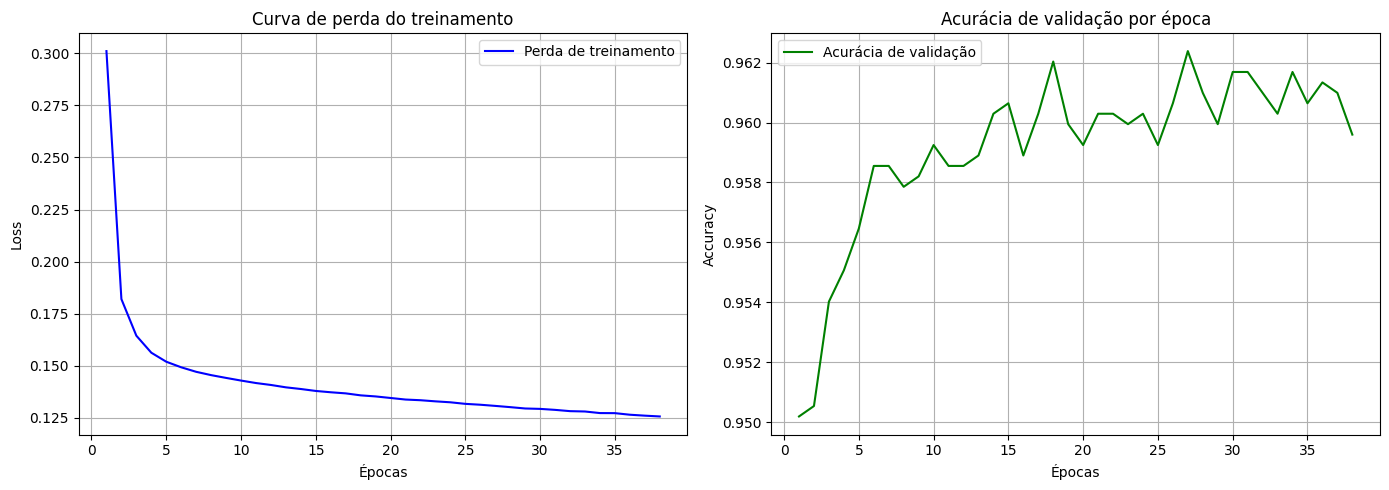

In [5]:
# ============================================================
# 10. DIVISÃO DO TREINO PARA BUSCA DOS PARÂMETROS
# ============================================================

# Como os dados já estão ordenados cronologicamente,
# usamos os primeiros 80% para treinamento e os últimos
# 20% para validação.

split_validacao = int(len(X_train) * 0.80)

X_treino_busca = X_train.iloc[:split_validacao].copy()
y_treino_busca = y_train.iloc[:split_validacao].copy()

X_validacao = X_train.iloc[split_validacao:].copy()
y_validacao = y_train.iloc[split_validacao:].copy()

print("\nDados utilizados na busca:")
print(f"Treinamento: {len(X_treino_busca):,}")
print(f"Validação:   {len(X_validacao):,}")


# ============================================================
# 11. TESTE DE TODAS AS CONFIGURAÇÕES
# ============================================================

resultados = []

total_configuracoes = len(combinacoes)

print("\n" + "=" * 70)
print("INICIANDO BUSCA DE HIPERPARÂMETROS")
print("=" * 70)

print(f"Total de configurações: {total_configuracoes}")

for numero, parametros in enumerate(combinacoes, start=1):

    print(
        f"\n[{numero}/{total_configuracoes}] "
        f"Testando: {parametros}"
    )

    mlp_teste = MLPClassifier(
        **FIXED_PARAMS,
        **parametros
    )

    mlp_teste.fit(
        X_treino_busca,
        y_treino_busca
    )

    # ========================================================
    # PREDIÇÃO NA VALIDAÇÃO
    # ========================================================

    y_prob_validacao = mlp_teste.predict_proba(
        X_validacao
    )[:, 1]

    y_pred_validacao = (
        y_prob_validacao >= THRESHOLD
    ).astype(int)

    # ========================================================
    # MÉTRICAS
    # ========================================================

    accuracy = accuracy_score(
        y_validacao,
        y_pred_validacao
    )

    precision = precision_score(
        y_validacao,
        y_pred_validacao,
        pos_label=1,
        zero_division=0
    )

    recall = recall_score(
        y_validacao,
        y_pred_validacao,
        pos_label=1,
        zero_division=0
    )

    f1 = f1_score(
        y_validacao,
        y_pred_validacao,
        pos_label=1,
        zero_division=0
    )

    f2 = fbeta_score(
        y_validacao,
        y_pred_validacao,
        beta=2,
        pos_label=1,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_validacao,
        y_prob_validacao
    )

    precision_pr, recall_pr, _ = precision_recall_curve(
        y_validacao,
        y_prob_validacao,
        pos_label=1
    )

    pr_auc = auc(
        recall_pr,
        precision_pr
    )

    # ========================================================
    # SALVA RESULTADO
    # ========================================================

    resultado = {
        **parametros,

        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "f2": f2,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,

        "epocas_executadas": mlp_teste.n_iter_
    }

    resultados.append(resultado)

    print(
        f"F2: {f2:.4f} | "
        f"Recall: {recall:.4f} | "
        f"Precision: {precision:.4f} | "
        f"PR-AUC: {pr_auc:.4f} | "
        f"Épocas: {mlp_teste.n_iter_}"
    )


# ============================================================
# 11.1 RANKING DAS CONFIGURAÇÕES
# ============================================================

resultados_df = pd.DataFrame(
    resultados
)

# Precision mínima desejada para a classe atraso
PRECISION_MINIMA = 0.10

# Mantém apenas as configurações que atingiram
# a precisão mínima
resultados_filtrados = resultados_df[
    resultados_df["precision"] >= PRECISION_MINIMA
].copy()

if len(resultados_filtrados) == 0:

    print(
        "\nNenhuma configuração atingiu "
        f"Precision >= {PRECISION_MINIMA:.2f}."
    )

    raise ValueError(
        "Aumente o número de combinações ou "
        "reduza a PRECISION_MINIMA."
    )

else:

    # Prioridade:
    # 1. maior Recall
    # 2. maior F2
    # 3. maior PR-AUC

    resultados_filtrados = resultados_filtrados.sort_values(
        by=["recall", "f2", "pr_auc"],
        ascending=False
    ).reset_index(drop=True)

    melhor_resultado = resultados_filtrados.iloc[0]

    print("\n" + "=" * 70)
    print("MELHORES CONFIGURAÇÕES")
    print("=" * 70)

    display(
        resultados_filtrados.head(10)
    )

# ============================================================
# 11.2 MELHOR CONFIGURAÇÃO
# ============================================================

# Usa a melhor configuração entre as que passaram no critério de precisão.
# Não usar resultados_df.iloc[0]: ele apenas pega a primeira combinação testada.
melhor_resultado = resultados_filtrados.iloc[0]

BEST_PARAMS = {
    "hidden_layer_sizes": melhor_resultado["hidden_layer_sizes"],
    "learning_rate_init": melhor_resultado["learning_rate_init"],
    "batch_size": int(melhor_resultado["batch_size"]),
    "alpha": melhor_resultado["alpha"],
    "max_iter": int(melhor_resultado["max_iter"])
}

MLP_PARAMS = {
    **FIXED_PARAMS,
    **BEST_PARAMS
}

print("\n" + "=" * 70)
print("MELHOR CONFIGURAÇÃO ENCONTRADA")
print("=" * 70)

print(f"Arquitetura:       {BEST_PARAMS['hidden_layer_sizes']}")
print(f"Learning rate:     {BEST_PARAMS['learning_rate_init']}")
print(f"Batch size:        {BEST_PARAMS['batch_size']}")
print(f"Alpha:             {BEST_PARAMS['alpha']}")
print(f"Max iter:          {BEST_PARAMS['max_iter']}")

print("\nParâmetros fixos:")
print(f"Activation:        {FIXED_PARAMS['activation']}")
print(f"Solver:            {FIXED_PARAMS['solver']}")

print("\nResultado na validação:")
print(f"Accuracy:           {melhor_resultado['accuracy']:.4f}")
print(f"Precision:          {melhor_resultado['precision']:.4f}")
print(f"Recall:             {melhor_resultado['recall']:.4f}")
print(f"F1:                 {melhor_resultado['f1']:.4f}")
print(f"F2:                 {melhor_resultado['f2']:.4f}")
print(f"ROC-AUC:            {melhor_resultado['roc_auc']:.4f}")
print(f"PR-AUC:             {melhor_resultado['pr_auc']:.4f}")


# ============================================================
# 11.3 TREINAMENTO FINAL COM A MELHOR CONFIGURAÇÃO
# ============================================================

print("\n" + "=" * 70)
print("TREINAMENTO FINAL")
print("=" * 70)

mlp = MLPClassifier(
    **MLP_PARAMS
)

mlp.fit(
    X_train,
    y_train
)

print(
    f"Épocas executadas no modelo final: {mlp.n_iter_}"
)


# ============================================================
# 11.4 SALVAMENTO DO MODELO FINAL
# ============================================================

# O modelo recebe 26 variáveis numéricas, mas a API recebe os campos brutos
# do formulário/CSV. Por isso, o artefato precisa carregar também os mapas
# de target encoding criados SOMENTE com o conjunto de treino.
encoding_maps = {
    "customer_city": {str(chave): float(valor) for chave, valor in smooth_customer.items()},
    "seller_city": {str(chave): float(valor) for chave, valor in smooth_seller.items()},
    "category_name": {str(chave): float(valor) for chave, valor in smooth_cat.items()},
}

raw_columns = [
    "purchase_date",
    "purchase_time",
    "carrier_datetime",
    "estimated_delivery_datetime",
    "price",
    "freight_value",
    "product_weight_g",
    "height_cm",
    "width_cm",
    "length_cm",
    "distance_km",
    "same_city",
    "customer_city",
    "seller_city",
    "category_name",
]

modelo = {
    # Objetos necessários para a inferência
    "model": mlp,
    "scaler": scaler,
    "features": X_train.columns.tolist(),
    "feature_names": X_train.columns.tolist(),
    "threshold": float(THRESHOLD),
    "params": MLP_PARAMS,

    # Dados necessários para repetir o pré-processamento da API
    "encoding_maps": encoding_maps,
    "global_delay_rate": float(media_global_atraso),
    "smoothing": int(m),
    "raw_columns": raw_columns,
    "inference_moment": "carrier_collection",
    "ecommerce_events": [
        "mothers_day", "fathers_day", "children_day",
        "black_friday", "cyber_monday", "christmas",
    ],

    # Contrato do artefato consumido pela API
    "schema_version": 3,
    "model_type": "MLPClassifier",
    "model_name": "MLP (Rede Neural)",
}

caminho_modelo = Path.cwd() / "modelo_mlp_final.pkl"

with open(
    caminho_modelo,
    "wb"
) as arquivo:

    pickle.dump(
        modelo,
        arquivo,
        protocol=pickle.HIGHEST_PROTOCOL
    )

print(
    f"\nModelo final salvo com sucesso em: "
    f"{caminho_modelo}"
)
print(f"Variáveis do modelo: {len(modelo['features'])}")
print(f"Mapas de encoding: {', '.join(modelo['encoding_maps'].keys())}")
print(f"Limiar de atraso: {modelo['threshold']:.2f}")


# ============================================================
# 11.2 GRÁFICOS DE TREINAMENTO E VALIDAÇÃO
# ============================================================

epocas = range(1, len(mlp.loss_curve_) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1 - Perda do treinamento
axes[0].plot(
    epocas,
    mlp.loss_curve_,
    label="Perda de treinamento",
    color="blue"
)

axes[0].set_title("Curva de perda do treinamento")
axes[0].set_xlabel("Épocas")
axes[0].set_ylabel("Loss")
axes[0].grid(True)
axes[0].legend()

# Gráfico 2 - Acurácia de validação
if mlp.validation_scores_ is not None:
    epocas_validacao = range(
        1,
        len(mlp.validation_scores_) + 1
    )

    axes[1].plot(
        epocas_validacao,
        mlp.validation_scores_,
        label="Acurácia de validação",
        color="green"
    )

    axes[1].set_title("Acurácia de validação por época")
    axes[1].set_xlabel("Épocas")
    axes[1].set_ylabel("Accuracy")
    axes[1].grid(True)
    axes[1].legend()

plt.tight_layout()
plt.show()

# Gráfico 01
A curva de perda mostra o erro que o modelo apresenta durante o treinamento.

Curva decrescente: o modelo está aprendendo a ajustar seus pesos.

Curva estabilizada: o treinamento pode ter atingido um platô.

Curva crescente: pode indicar instabilidade ou dificuldades de otimização.

# Gráfico 02

A curva de validação mostra como o modelo classifica as amostras reservadas para validação durante o treinamento.

Acurácia crescente: o modelo está melhorando sua capacidade de classificação no conjunto de validação.

Acurácia estabilizada: pode indicar que o modelo deixou de apresentar melhorias.

Acurácia decrescente: pode indicar que o modelo está perdendo capacidade de generalização.

In [6]:
# ============================================================
# 12. PREDIÇÃO
# ============================================================

y_prob = mlp.predict_proba(
    X_test
)[:, 1]

y_pred = (
    y_prob >= THRESHOLD
).astype(int)

In [7]:
# ============================================================
# 13. MÉTRICAS
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision_atraso = precision_score(
    y_test,
    y_pred,
    pos_label=1,
    zero_division=0
)

recall_atraso = recall_score(
    y_test,
    y_pred,
    pos_label=1,
    zero_division=0
)

f1_atraso = f1_score(
    y_test,
    y_pred,
    pos_label=1,
    zero_division=0
)

f2_atraso = fbeta_score(
    y_test,
    y_pred,
    beta=2,
    pos_label=1,
    zero_division=0
)

roc_auc_atraso = roc_auc_score(
    y_test,
    y_prob
)

precision_pr, recall_pr, _ = precision_recall_curve(
    y_test,
    y_prob,
    pos_label=1
)

pr_auc_atraso = auc(
    recall_pr,
    precision_pr
)


RESULTADOS - MLP
Arquitetura: (64, 32, 16)
Activation: relu
Solver: adam
Learning rate: 0.0003
Batch size: 128
Épocas máximas: 50
Limiar: 0.30

Quantidade de amostras:
Treino: 28706
Teste:  5114

Métricas:
Accuracy:        0.8283
Precision atraso: 0.3895
Recall atraso:    0.7618
F1 atraso:        0.5155
F2 atraso:        0.6396
ROC-AUC atraso:   0.8785
PR-AUC atraso:    0.6016

Como interpretar as métricas:
- Precision atraso: entre os pedidos previstos como atraso, quantos realmente atrasaram.
- Recall atraso: entre os pedidos que realmente atrasaram, quantos o modelo conseguiu detectar.
- F1 atraso: média harmônica entre precision e recall.
- F2 atraso: semelhante ao F1, mas dando mais peso ao recall.
- ROC-AUC atraso: capacidade do modelo de separar atrasos de não atrasos em diferentes limiares.
- PR-AUC atraso: desempenho no equilíbrio entre precision e recall para a classe atraso.


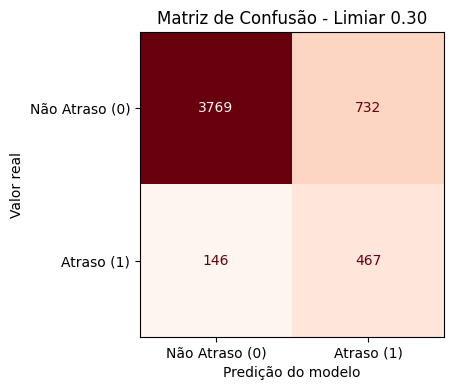


Relatório de classificação:
                precision    recall  f1-score   support

Não Atraso (0)       0.96      0.84      0.90      4501
    Atraso (1)       0.39      0.76      0.52       613

      accuracy                           0.83      5114
     macro avg       0.68      0.80      0.71      5114
  weighted avg       0.89      0.83      0.85      5114


Quantidade de épocas executadas:
38


In [8]:
# ============================================================
# 14. RESULTADOS
# ============================================================

print("\n" + "=" * 60)
print("RESULTADOS - MLP")
print("=" * 60)

print(f"Arquitetura: {MLP_PARAMS['hidden_layer_sizes']}")
print(f"Activation: {MLP_PARAMS['activation']}")
print(f"Solver: {MLP_PARAMS['solver']}")
print(f"Learning rate: {MLP_PARAMS['learning_rate_init']}")
print(f"Batch size: {MLP_PARAMS['batch_size']}")
print(f"Épocas máximas: {MLP_PARAMS['max_iter']}")
print(f"Limiar: {THRESHOLD:.2f}")

print("\nQuantidade de amostras:")
print(f"Treino: {len(X_train)}")
print(f"Teste:  {len(X_test)}")

print("\nMétricas:")
print(f"Accuracy:        {accuracy:.4f}")
print(f"Precision atraso: {precision_atraso:.4f}")
print(f"Recall atraso:    {recall_atraso:.4f}")
print(f"F1 atraso:        {f1_atraso:.4f}")
print(f"F2 atraso:        {f2_atraso:.4f}")
print(f"ROC-AUC atraso:   {roc_auc_atraso:.4f}")
print(f"PR-AUC atraso:    {pr_auc_atraso:.4f}")

# ============================================================
# INTERPRETAÇÃO DAS MÉTRICAS
# ============================================================

print("\nComo interpretar as métricas:")
print("- Precision atraso: entre os pedidos previstos como atraso, quantos realmente atrasaram.")
print("- Recall atraso: entre os pedidos que realmente atrasaram, quantos o modelo conseguiu detectar.")
print("- F1 atraso: média harmônica entre precision e recall.")
print("- F2 atraso: semelhante ao F1, mas dando mais peso ao recall.")
print("- ROC-AUC atraso: capacidade do modelo de separar atrasos de não atrasos em diferentes limiares.")
print("- PR-AUC atraso: desempenho no equilíbrio entre precision e recall para a classe atraso.")

# ============================================================
# MATRIZ DE CONFUSÃO
# ============================================================

fig, ax = plt.subplots(figsize=(5, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Reds",
    ax=ax,
    colorbar=False,
    display_labels=[
        "Não Atraso (0)",
        "Atraso (1)"
    ]
)

ax.set_title(
    f"Matriz de Confusão - Limiar {THRESHOLD:.2f}"
)

ax.set_xlabel("Predição do modelo")
ax.set_ylabel("Valor real")

plt.tight_layout()
plt.show()

# ============================================================
# RELATÓRIO DE CLASSIFICAÇÃO
# ============================================================

print("\nRelatório de classificação:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Não Atraso (0)",
            "Atraso (1)"
        ],
        zero_division=0
    )
)

print("\nQuantidade de épocas executadas:")
print(mlp.n_iter_)

Esse resultado mostra um problema bem claro no MLP: **ele praticamente não está aprendendo a identificar os atrasos**.

Pelos números:

```text
Matriz de confusão:

[[   1  612]
 [  15 4486]]
```

Considerando `0 = atraso` e `1 = no prazo`:

|                   | Predito atraso | Predito no prazo |
| ----------------- | -------------- | ---------------- |
| **Real atraso**   | 1              | 612              |
| **Real no prazo** | 15             | 4486             |

Ou seja:

* **613 entregas estavam atrasadas**
* O modelo identificou apenas **1**
* Deixou passar **612 atrasos**
* Identificou **4.486 entregas no prazo** corretamente

Isso explica:

```text
Accuracy: 0.8774
Recall:   0.0016
F1:       0.0032
F2:       0.0020
```

A accuracy de **87,74% parece boa**, mas é enganosa nesse problema porque a classe "no prazo" é muito maior.

### O problema aparece claramente no ROC-AUC

```text
ROC-AUC: 0.4735
```

Um modelo com capacidade discriminativa razoável deveria ficar acima de 0,5; **0,4735 indica que, com essa configuração, o MLP não está conseguindo separar adequadamente as duas classes**.

E o fato de ele ter parado em:

```text
21 épocas
```

não é necessariamente um erro. Você habilitou:

```python
"early_stopping": True,
"validation_fraction": 0.1,
"n_iter_no_change": 10,
```

Então o `MLPClassifier` interrompeu o treinamento quando não encontrou melhoria suficiente na validação.

---

## O principal problema provavelmente é o desbalanceamento

Seu teste tem:

```text
Atraso:    613
No prazo: 4501
```

Ou aproximadamente:

```text
12% atraso
88% no prazo
```

Então o modelo encontra uma estratégia muito fácil:

> "Quase tudo está no prazo."

E isso produz aproximadamente os 88% de accuracy que você está vendo.

Isso é particularmente importante no seu TCC porque você **não quer apenas prever a classe majoritária**. O objetivo é justamente identificar os pedidos que irão atrasar.

---

## Tem outro ponto importante no seu código

Você está calculando:

```python
precision_score(
    y_test,
    y_pred,
    pos_label=0
)
```

Isso está correto **se no seu projeto `0 = atraso`**.

E:

```python
recall_score(..., pos_label=0)
```

também está correto.

Então seus indicadores estão realmente medindo a capacidade de detectar **atrasos**, que é o que interessa.
